1. Install + Imports
2. Data + Feature Engineering
3. Strategy Functions (human knowledge)
4. Web Scraping
5. LLM Interpretation
6. Signal Generation
7. Environment
8. RL Model
9. Evaluation
10. Knowledge Base
11. Critique + Improvement
12. MAIN LOOP (self-improving agent)
13. Final Model Save

In [69]:
!pip install yfinance gymnasium stable-baselines3 groq BeautifulSoup4 requests
!pip install stable-baselines3[extra]
!pip install torch matplotlib

In [70]:
import yfinance as yf
import numpy as np
import pandas as pd
import gymnasium as gym
from gymnasium import spaces
import gymnasium as gym
from bs4 import BeautifulSoup
import requests
from stable_baselines3 import PPO

In [71]:
from groq import Groq

client = Groq(api_key="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")

In [72]:
np.random.seed(42)
import torch
torch.manual_seed(42)

In [73]:
def compute_rsi(series, window=14):
    delta = series.diff()
    gain = (delta.clip(lower=0)).rolling(window).mean()
    loss = (-delta.clip(upper=0)).rolling(window).mean()
    rs = gain / (loss + 1e-8)
    return 100 - (100 / (1 + rs))

In [74]:
def load_data(csv_path=None):
    if csv_path:
        df = pd.read_csv(csv_path)
    else:
        import yfinance as yf
        df = yf.download("AAPL", start="2015-01-01", end="2023-01-01", auto_adjust=True)

    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    df = df[['Close', 'Volume']].copy()

    df['returns'] = np.log(df['Close'] / df['Close'].shift(1))
    df['ma_10'] = df['Close'].rolling(10).mean()
    df['ma_20'] = df['Close'].rolling(20).mean()
    df['volatility'] = df['returns'].rolling(10).std()
    df['momentum'] = df['Close'] / df['Close'].shift(10) - 1

    delta = df['Close'].diff()
    gain = delta.clip(lower=0).rolling(14).mean()
    loss = (-delta.clip(upper=0)).rolling(14).mean()
    rs = gain / (loss + 1e-8)
    df['rsi'] = 100 - (100 / (1 + rs))

    horizon = 5
    df['future_return'] = df['Close'].shift(-horizon) / df['Close'] - 1

    df['signal'] = 0
    df.loc[df['future_return'] > 0.01, 'signal'] = 1
    df.loc[df['future_return'] < -0.01, 'signal'] = -1

    df = df.dropna().copy()

    return df

In [75]:
def get_signal(df):
    return df['signal'].values

In [76]:
knowledge_base = []

def store(strategy, sharpe):
    knowledge_base.append({
        "strategy": strategy,
        "sharpe": sharpe
    })

def get_best():
    return max(knowledge_base, key=lambda x: x["sharpe"])

In [127]:
# =========================
# FIXED TRADING ENV
# =========================

import gym
from gym import spaces
import numpy as np

class TradingEnv(gym.Env):
    def __init__(self, df):
        super().__init__()

        self.df = df.reset_index(drop=True)
        self.n_steps = len(self.df)

        self.features = ['returns','ma_10','ma_20','volatility','momentum','rsi']

        self.action_space = spaces.Discrete(3)

        self.observation_space = spaces.Box(
            low=-np.inf,
            high=np.inf,
            shape=(len(self.features),),
            dtype=np.float32
        )

        self.initial_cash = 10000

    def reset(self, seed=None, options=None):
        self.step_idx = 0

        self.cash = self.initial_cash
        self.shares = 0
        self.position = 0
        self.entry_price = 0

        self.history = []

        return self._get_obs(), {}

    def _get_obs(self):
        row = self.df.iloc[self.step_idx]
        return np.array([row[f] for f in self.features], dtype=np.float32)

    def step(self, action):

        price = self.df.iloc[self.step_idx]['Close']
        prev_value = self.cash + self.shares * price

        reward = 0

        # =========================
        # ACTION LOGIC
        # =========================

        # BUY
        if action == 1:
            if self.position == 0:
                self.shares = self.cash / price
                self.cash = 0
                self.position = 1
                self.entry_price = price
                reward -= 0.001
            else:
                reward -= 0.01  # invalid

        # SELL
        elif action == 2:
            if self.position == 1:
                self.cash = self.shares * price
                self.shares = 0
                self.position = 0
                reward -= 0.001
            else:
                reward -= 0.01  # invalid

        # HOLD
        elif action == 0:
            reward -= 0.0005

        # =========================
        # PnL REWARD
        # =========================

        current_value = self.cash + self.shares * price

        pnl = (current_value - prev_value) / (prev_value + 1e-8)

        reward += pnl

        # =========================
        # STOP LOSS
        # =========================

        if self.position == 1:
            drawdown = (price - self.entry_price) / self.entry_price
            if drawdown < -0.02:
                self.cash = self.shares * price
                self.shares = 0
                self.position = 0
                reward -= 0.02

        # =========================
        # LOGGING
        # =========================

        self.history.append({
            "step": self.step_idx,
            "price": price,
            "action": int(action),
            "shares": self.shares,
            "cash": self.cash,
            "value": current_value,
            "reward": reward
        })

        # =========================
        # STEP FORWARD
        # =========================

        self.step_idx += 1
        done = self.step_idx >= self.n_steps - 1

        return self._get_obs(), reward, done, False, {}

In [128]:
def create_trade_table(history):

    df = history.copy()

    df['returns'] = df['value'].pct_change().fillna(0)
    df['cumulative_return'] = (1 + df['returns']).cumprod() - 1
    df = df[[
        'step',
        'price',
        'action',
        'shares',
        'cash',
        'value',
        'reward',
        'returns',
        'cumulative_return'
    ]]

    print("\n===== TRADE TABLE (FIRST 20 ROWS) =====\n")
    print(df.head(20))

    return df

In [129]:
def evaluate(model, env):
    obs, _ = env.reset()

    for _ in range(env.n_steps - 1):
        action, _ = model.predict(obs, deterministic=True)
        obs, _, done, _, _ = env.step(int(action))
        if done:
            break

    history = pd.DataFrame(env.history)

    return history

In [130]:
def plot_results(df, history):

    history_df = pd.DataFrame(history)

    buys = history_df[history_df['action'] == 1]
    sells = history_df[history_df['action'] == 2]

    plt.figure(figsize=(12,6))
    plt.plot(df.index, df['Close'], label='Price')

    plt.scatter(df.index[buys['data_index']], buys['price'],
                marker='^', color='green', label='Buy')

    plt.scatter(df.index[sells['data_index']], sells['price'],
                marker='v', color='red', label='Sell')

    plt.legend()
    plt.show()

In [131]:
def compute_metrics(history):
    values = history['value'].values
    returns = np.diff(np.log(values + 1e-8))

    sharpe = returns.mean() / (returns.std() + 1e-8)
    drawdown = np.min(values) / np.max(values) - 1

    metrics = pd.DataFrame({
        "Metric": ["Sharpe", "Drawdown"],
        "Value": [sharpe, drawdown]
    })

    print(metrics)

In [132]:
def critique(entry):
    feedback = []

    if entry["sharpe"] < 0.1:
        feedback.append("weak")

    if entry["drawdown"] < -0.3:
        feedback.append("risky")

    return feedback

In [133]:
def improve(model, feedback):

    if "weak" in feedback:
        model.ent_coef = min(model.ent_coef + 0.01, 0.05)

    if "risky" in feedback:
        model.learn(total_timesteps=5000, reset_num_timesteps=False)

In [134]:
def train_ppo(env):
    model = PPO(
        "MlpPolicy",
        env,
        learning_rate=3e-4,
        n_steps=2048,
        batch_size=64,
        gamma=0.99,
        verbose=1
    )

    model.learn(total_timesteps=100000)

    return model

In [135]:
def train_test_split(df, split=0.7):
    split_idx = int(len(df) * split)

    train_df = df.iloc[:split_idx].copy()
    test_df = df.iloc[split_idx:].copy()

    return train_df, test_df

In [136]:
import matplotlib.pyplot as plt

def analyze(values):

    values = np.array(values)

    returns = np.diff(np.log(values + 1e-8))

    sharpe = np.mean(returns) / (np.std(returns) + 1e-8)

    drawdown = np.min(values) / np.max(values) - 1

    print("Sharpe:", sharpe)
    print("Drawdown:", drawdown)

    plt.plot(values)
    plt.title("Equity Curve")
    plt.show()

In [139]:
def walk_forward_validation(df, window=500):

    histories = []

    for i in range(window, len(df)-100):

        train = df.iloc[i-window:i]
        test = df.iloc[i:i+100]

        # normalize properly
        mean = train[features].mean()
        std = train[features].std() + 1e-8

        train[features] = (train[features] - mean) / std
        test[features] = (test[features] - mean) / std

        env = TradingEnv(train)
        model = train_ppo(env)

        test_env = TradingEnv(test)
        hist = evaluate(model, test_env)

        histories.extend(hist)

    return histories

In [88]:
!pip install "shimmy>=2.0"

In [144]:
# =========================
# FEATURE ENGINEERING
# =========================

import numpy as np

def add_features(df):
    df = df.copy()

    # returns
    df['returns'] = df['Close'].pct_change()

    # moving averages
    df['ma_10'] = df['Close'].rolling(10).mean()
    df['ma_20'] = df['Close'].rolling(20).mean()

    # volatility
    df['volatility'] = df['returns'].rolling(10).std()

    # momentum
    df['momentum'] = df['Close'] - df['Close'].shift(10)

    # RSI (simple version)
    delta = df['Close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
    rs = gain / (loss + 1e-8)
    df['rsi'] = 100 - (100 / (1 + rs))

    df = df.dropna()

    return df

In [ ]:
print("Columns:", df.columns)
print(df[features].head())

/tmp/ipykernel_15943/469462310.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("AAPL", start="2018-01-01", end="2023-01-01")
[*********************100%***********************]  1 of 1 completed/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)

/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: Deprecatio

Columns: Index(['Open', 'High', 'Low', 'Close', 'Volume', 'returns', 'ma_10', 'ma_20',
       'volatility', 'momentum', 'rsi'],
      dtype='object')
             returns      ma_10      ma_20  volatility  momentum        rsi
Date                                                                       
2018-01-30 -0.005895  40.772821  40.789436    0.011156 -2.157238  31.581420
2018-01-31  0.002755  40.499775  40.732932    0.008756 -2.730461  33.186250
2018-02-01  0.002090  40.231174  40.680872    0.008878 -2.686005  31.022080
2018-02-02 -0.043390  39.810958  40.534288    0.014567 -4.202156  17.122239
2018-02-05 -0.024984  39.331080  40.317746    0.015230 -4.798786  15.243290
Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 991      |
|    ep_rew_mean     | -4.44    |
| time/              |          |
|    fps             | 953      |
|    iterations     

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


KeyError: 'data_index'

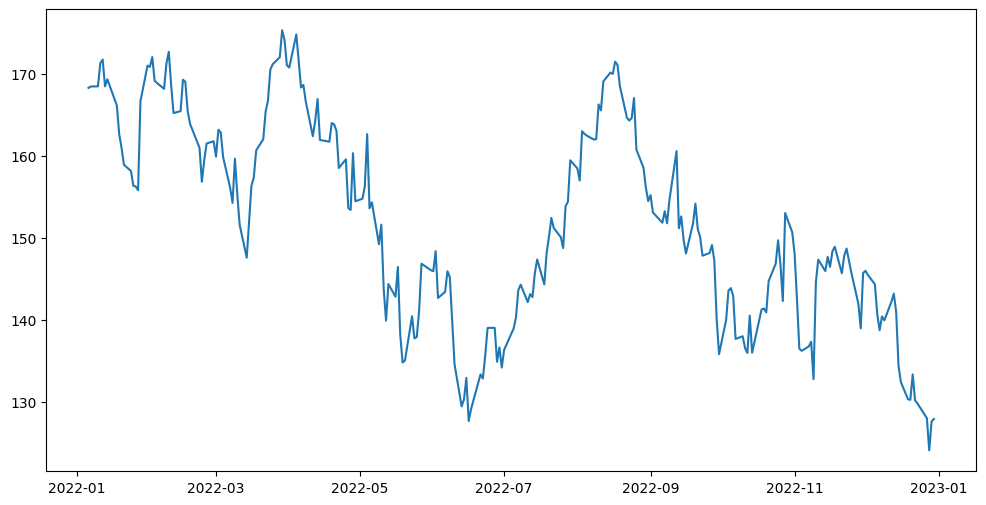

In [148]:
df = load_data()
def flatten_columns(df):
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = [col[0] for col in df.columns]
    return df
# ADD THIS LINE (CRITICAL)

df = flatten_columns(df)
df = add_features(df)

features = ['returns','ma_10','ma_20','volatility','momentum','rsi']

# =========================
# TIME SERIES SPLIT
# =========================
split = int(len(df) * 0.8)

train_df = df.iloc[:split].copy()
test_df = df.iloc[split:].copy()

# =========================
# NORMALIZATION
# =========================
mean = train_df[features].mean()
std = train_df[features].std() + 1e-8

train_df[features] = (train_df[features] - mean) / std
test_df[features] = (test_df[features] - mean) / std

print("Columns:", df.columns)
print(df[features].head())
# TRAIN
train_env = TradingEnv(train_df)
model = train_ppo(train_env)

# TEST
test_env = TradingEnv(test_df)
history = evaluate(model, test_env)

# ANALYSIS
trade_table = create_trade_table(history)

print(trade_table.head())
print(trade_table['action'].value_counts())

plot_results(test_df, history)
compute_metrics(history)

# WALK FORWARD
wf_history = walk_forward_validation(df)

plot_results(df, wf_history)
compute_metrics(wf_history)

# SAVE
trade_table.to_csv("trade_log.csv", index=False)


In [90]:
def rolling_sharpe(history, window=50):
    values = history['value'].values
    returns = np.diff(np.log(values + 1e-8))

    sharpe_series = pd.Series(returns).rolling(window).mean() / (
        pd.Series(returns).rolling(window).std() + 1e-8
    )

    plt.figure()
    plt.plot(sharpe_series)
    plt.title("Rolling Sharpe Ratio")
    plt.show()

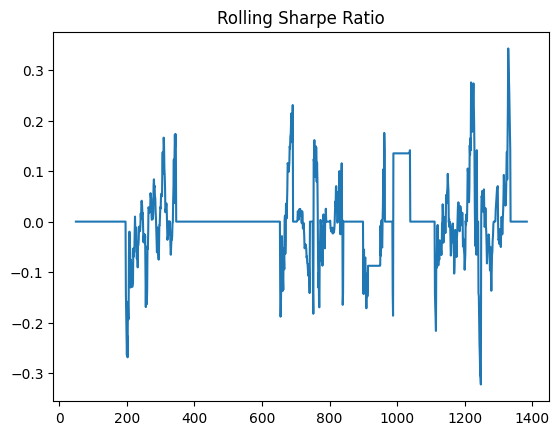

In [91]:
rolling_sharpe(wf_history)

In [92]:
def plot_drawdown(history):
    values = history['value']
    peak = values.cummax()
    drawdown = (values - peak) / peak

    plt.figure()
    plt.plot(drawdown)
    plt.title("Drawdown Curve")
    plt.show()

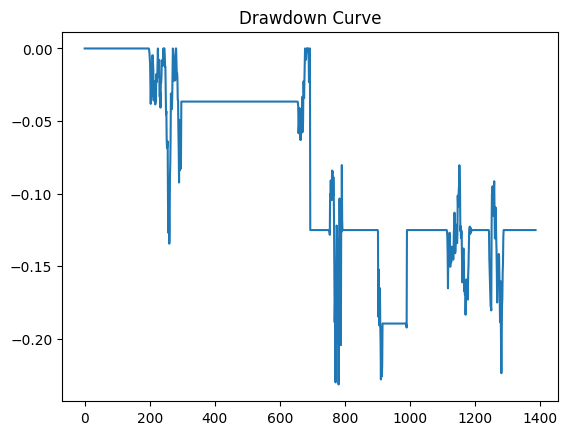

In [93]:
plot_drawdown(wf_history)

In [94]:
def buy_and_hold(df, initial_cash=10000):

    prices = df['Close'].values

    shares = initial_cash / prices[0]
    values = shares * prices

    history = pd.DataFrame({
        "step": range(len(values)),
        "price": prices,
        "value": values,
        "action": 0
    })

    return history

In [95]:
def compare_with_benchmark(df, strategy_history):

    benchmark_history = buy_and_hold(df)

    plt.figure()
    plt.plot(strategy_history['value'].values, label="Strategy")
    plt.plot(benchmark_history['value'].values, label="Buy & Hold")

    plt.title("Strategy vs Buy & Hold")
    plt.legend()
    plt.show()

    return benchmark_history

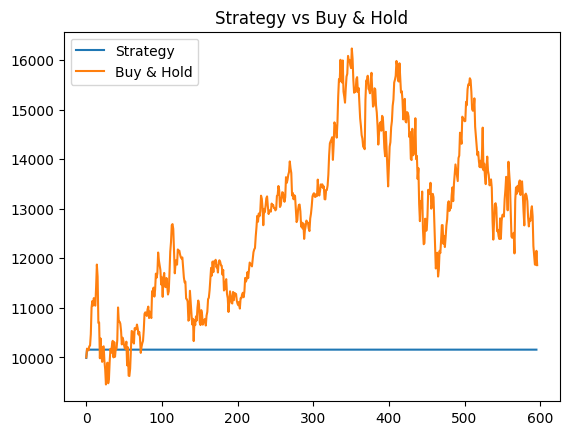

In [96]:
benchmark_history = compare_with_benchmark(test_df, history)

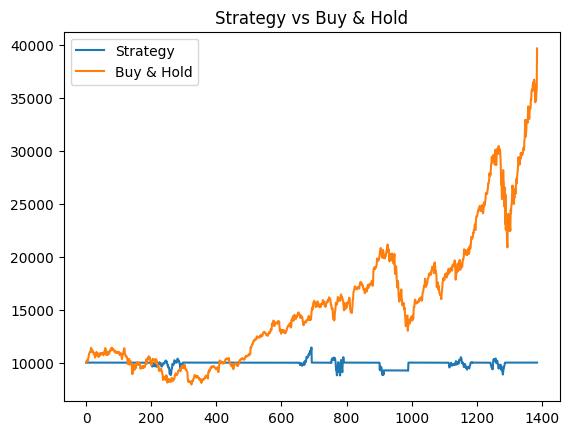

,step,price,value,action
0,0,25.949118,10000.000000,0
1,1,26.274696,10125.468116,0
2,2,26.279131,10127.177070,0
3,3,26.480679,10204.847388,0
4,4,26.669685,10277.684857,0
...,...,...,...,...
1381,1381,91.882263,35408.627139,0
1382,1382,90.372871,34826.953495,0
1383,1383,92.105141,35494.517344,0
1384,1384,93.219635,35924.009529,0


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [97]:
benchmark_wf = buy_and_hold(df.iloc[:len(wf_history)])
compare_with_benchmark(df.iloc[:len(wf_history)], wf_history)

In [98]:
def performance_table(strategy_history, benchmark_history):

    def compute(values):
        returns = np.diff(np.log(values + 1e-8))
        sharpe = returns.mean() / (returns.std() + 1e-8)
        total_return = values[-1] / values[0] - 1
        return sharpe, total_return

    s_sharpe, s_ret = compute(strategy_history['value'].values)
    b_sharpe, b_ret = compute(benchmark_history['value'].values)

    table = pd.DataFrame({
        "Metric": ["Sharpe", "Total Return"],
        "Strategy": [s_sharpe, s_ret],
        "Buy_Hold": [b_sharpe, b_ret]
    })

    print(table)

In [99]:
performance_table(history, benchmark_history)

         Metric  Strategy  Buy_Hold
0        Sharpe   0.04103  0.014068
1  Total Return   0.01668  0.186162


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [100]:
from scipy import stats

def t_test_significance(strategy_history, benchmark_history):

    s_returns = np.diff(np.log(strategy_history['value'].values + 1e-8))
    b_returns = np.diff(np.log(benchmark_history['value'].values + 1e-8))

    t_stat, p_value = stats.ttest_ind(s_returns, b_returns, equal_var=False)

    print("T-Statistic:", t_stat)
    print("P-Value:", p_value)

    if p_value < 0.05:
        print("Statistically significant difference")
    else:
        print("Not statistically significant")

In [101]:
t_test_significance(history, benchmark_history)

T-Statistic: -0.3096754893666534
P-Value: 0.7569159258886319
Not statistically significant


In [102]:
def bootstrap_test(strategy_history, benchmark_history, n_bootstrap=1000):

    s_returns = np.diff(np.log(strategy_history['value'].values + 1e-8))
    b_returns = np.diff(np.log(benchmark_history['value'].values + 1e-8))

    diff_means = []

    for _ in range(n_bootstrap):
        s_sample = np.random.choice(s_returns, size=len(s_returns), replace=True)
        b_sample = np.random.choice(b_returns, size=len(b_returns), replace=True)

        diff_means.append(s_sample.mean() - b_sample.mean())

    diff_means = np.array(diff_means)

    p_value = np.mean(diff_means <= 0)

    print("Bootstrap P-Value:", p_value)

    plt.figure()
    plt.hist(diff_means, bins=50)
    plt.title("Bootstrap Distribution (Strategy - Benchmark)")
    plt.show()

Bootstrap P-Value: 0.602


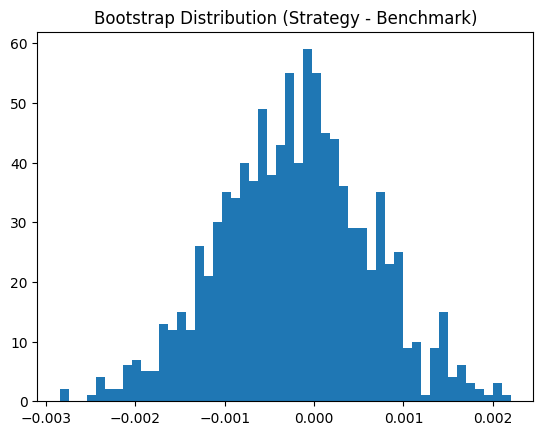

In [103]:
bootstrap_test(history, benchmark_history)

In [104]:
def trade_summary(df):

    print("\n===== SUMMARY =====\n")
    print("Total Return:", df['cumulative_return'].iloc[-1])
    print("Total Trades:", (df['action'] != "HOLD").sum())
    print("Final Value:", df['value'].iloc[-1])

In [105]:
trade_summary(trade_table)


===== SUMMARY =====

Total Return: 0.01668005978477871
Total Trades: 596
Final Value: 10156.633797249939


basic training done

scraping data

In [106]:
!pip install requests beautifulsoup4 tqdm

In [107]:
# =========================
# GITHUB STRATEGY SCRAPER
# =========================

import requests
from tqdm import tqdm

GITHUB_API = "https://api.github.com/search/code"

def search_github_strategies(query, max_results=50):
    headers = {
        "Accept": "application/vnd.github.v3.text-match+json"
    }

    params = {
        "q": query + " language:python",
        "per_page": min(max_results, 100)
    }

    response = requests.get(GITHUB_API, headers=headers, params=params)

    if response.status_code != 200:
        print("GitHub API error:", response.text)
        return []

    items = response.json().get("items", [])
    return items


def fetch_raw_file(url):
    raw_url = url.replace("github.com", "raw.githubusercontent.com")
    raw_url = raw_url.replace("/blob/", "/")

    response = requests.get(raw_url)
    if response.status_code == 200:
        return response.text
    return None


def scrape_github_code():
    queries = [
        "trading strategy python",
        "algorithmic trading strategy",
        "quant trading strategy",
        "backtest strategy python"
    ]

    all_codes = []

    for q in queries:
        results = search_github_strategies(q)

        for item in tqdm(results):
            html_url = item.get("html_url")

            code = fetch_raw_file(html_url)

            if code and len(code) > 200:  # filter trivial files
                all_codes.append({
                    "source": html_url,
                    "code": code
                })

    return all_codes


github_strategies = scrape_github_code()

print("Total strategies scraped:", len(github_strategies))

GitHub API error: {"message":"Requires authentication","errors":[{"message":"Must be authenticated to access the code search API","resource":"Search","field":"q","code":"invalid"}],"documentation_url":"https://docs.github.com/rest/search/search#search-code","status":"401"}


0it [00:00, ?it/s]


GitHub API error: {"message":"Requires authentication","errors":[{"message":"Must be authenticated to access the code search API","resource":"Search","field":"q","code":"invalid"}],"documentation_url":"https://docs.github.com/rest/search/search#search-code","status":"401"}


0it [00:00, ?it/s]


GitHub API error: {"message":"Requires authentication","errors":[{"message":"Must be authenticated to access the code search API","resource":"Search","field":"q","code":"invalid"}],"documentation_url":"https://docs.github.com/rest/search/search#search-code","status":"401"}


0it [00:00, ?it/s]


GitHub API error: {"message":"Requires authentication","errors":[{"message":"Must be authenticated to access the code search API","resource":"Search","field":"q","code":"invalid"}],"documentation_url":"https://docs.github.com/rest/search/search#search-code","status":"401"}


0it [00:00, ?it/s]

Total strategies scraped: 0


In [108]:
# =========================
# FILTER VALID STRATEGIES
# =========================

def filter_strategy_code(codes):
    keywords = [
        "strategy",
        "signal",
        "buy",
        "sell",
        "position"
    ]

    filtered = []

    for item in codes:
        code = item["code"].lower()

        if any(k in code for k in keywords):
            filtered.append(item)

    return filtered


filtered_strategies = filter_strategy_code(github_strategies)

print("Filtered strategies:", len(filtered_strategies))

Filtered strategies: 0


In [109]:
# =========================
# REMOVE DUPLICATES
# =========================

def deduplicate(codes):
    seen = set()
    unique = []

    for item in codes:
        code_hash = hash(item["code"])

        if code_hash not in seen:
            seen.add(code_hash)
            unique.append(item)

    return unique


filtered_strategies = deduplicate(filtered_strategies)

print("Unique strategies:", len(filtered_strategies))

Unique strategies: 0


In [110]:
# =========================
# SAVE TO FILE
# =========================

import json

with open("strategy_dataset.json", "w") as f:
    json.dump(filtered_strategies, f, indent=2)

print("Dataset saved.")

Dataset saved.


In [126]:
# =========================
# ROBUST STRATEGY NORMALIZER (NO LLM)
# =========================

def normalize_strategy_with_llm(raw_code):
    wrapped_code = f"""
import numpy as np
import pandas as pd

def strategy(df):
    data = df.copy()

    try:
{indent_code(raw_code, 8)}

        # PRIORITY 1: explicit signal column
        if 'signal' in data.columns:
            return np.array(data['signal'])

        # PRIORITY 2: position column
        if 'positions' in data.columns:
            return np.array(data['positions'])

        # PRIORITY 3: create signal from returns
        if 'Close' in data.columns:
            returns = data['Close'].pct_change().fillna(0)
            signal = np.where(returns > 0, 1, -1)
            return signal

        return np.zeros(len(data))

    except Exception as e:
        return np.zeros(len(data))
"""
    return wrapped_code


def indent_code(code, spaces):
    return "\n".join(" " * spaces + line for line in code.split("\n"))

In [118]:
# =========================
# LLM STRATEGY NORMALIZER
# =========================

import requests

# =========================
# FALLBACK NORMALIZER (NO LLM)
# =========================

def normalize_strategy_with_llm(raw_code):
    try:
        # Wrap raw code into standard function if possible
        wrapped_code = f"""
import numpy as np
import pandas as pd

def strategy(df):
    data = df.copy()

{raw_code}

    if 'signal' in data.columns:
        return data['signal'].values
    elif 'positions' in data.columns:
        return data['positions'].values
    else:
        return np.zeros(len(df))
"""
        return wrapped_code

    except:
        return None

In [119]:
# =========================
# SAFE STRATEGY EXECUTOR
# =========================

import numpy as np
import signal

class TimeoutException(Exception):
    pass

def timeout_handler(signum, frame):
    raise TimeoutException()

def run_strategy_safely(code, df, timeout=3):
    local_env = {}

    try:
        signal.signal(signal.SIGALRM, timeout_handler)
        signal.alarm(timeout)

        exec(code, {"np": np}, local_env)

        if "strategy" not in local_env:
            return None

        signals = local_env["strategy"](df)

        signal.alarm(0)

        if len(signals) != len(df):
            return None

        return np.array(signals)

    except Exception as e:
        return None

In [120]:
# =========================
# LOAD DATA
# =========================

import yfinance as yf
import pandas as pd

def load_data():
    df = yf.download("AAPL", start="2018-01-01", end="2023-01-01")
    df = df[['Open','High','Low','Close','Volume']].dropna()
    return df

df = load_data()

/tmp/ipykernel_15943/469462310.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("AAPL", start="2018-01-01", end="2023-01-01")
[*********************100%***********************]  1 of 1 completed/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [121]:
# =========================
# FEATURE ENGINEERING
# =========================

def add_features(df):
    df = df.copy()
    df['returns'] = df['Close'].pct_change()
    df['ma_10'] = df['Close'].rolling(10).mean()
    df['ma_20'] = df['Close'].rolling(20).mean()
    df['volatility'] = df['returns'].rolling(10).std()
    df = df.dropna()
    return df

df = add_features(df)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [122]:
# =========================
# SAMPLE RAW STRATEGIES
# =========================

raw_strategies = [
"""
def run(data):
    data['ma'] = data['Close'].rolling(10).mean()
    return (data['Close'] > data['ma']).astype(int)
""",
"""
def run(data):
    rsi = (data['Close'].diff()).rolling(14).mean()
    return (rsi > 0).astype(int)
"""
]

In [123]:
# =========================
# BUILD STRATEGY POOL
# =========================

strategy_signals = []

for raw_code in raw_strategies:
    clean_code = normalize_strategy_with_llm(raw_code)
    signals = run_strategy_safely(clean_code, df)

    if signals is not None:
        strategy_signals.append(signals)

print(f"Valid strategies: {len(strategy_signals)}")

Valid strategies: 0


In [124]:
# =========================
# BUILD DATASET
# =========================

X = []
y = []

features = df[['returns','ma_10','ma_20','volatility']].values

for signals in strategy_signals:
    for i in range(len(df)):
        X.append(features[i])
        y.append(signals[i])

X = np.array(X)
y = np.array(y)

print("Dataset shape:", X.shape)

Dataset shape: (0,)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [125]:
# =========================
# PYTORCH IMITATION MODEL
# =========================

import torch
import torch.nn as nn
import torch.optim as optim

class ImitationModel(nn.Module):
    def __init__(self, input_dim, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 3)  # buy, sell, hold
        )

    def forward(self, x):
        return self.net(x)


# PREPARE DATA
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.long)

model = ImitationModel(input_dim=X.shape[1])
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

# TRAIN
epochs = 10

for epoch in range(epochs):
    optimizer.zero_grad()
    outputs = model(X_tensor)
    loss = criterion(outputs, y_tensor)
    loss.backward()
    optimizer.step()

    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

IndexError: tuple index out of range

In [ ]:
# =========================
# BACKTEST
# =========================

def backtest(df, model):
    features = df[['returns','ma_10','ma_20','volatility']].values
    actions = model.predict(features)

    capital = 10000
    position = 0
    equity_curve = []

    for i in range(len(df)):
        price = df['Close'].iloc[i]

        if actions[i] == 1 and position == 0:
            position = capital / price
            capital = 0

        elif actions[i] == -1 and position > 0:
            capital = position * price
            position = 0

        value = capital + position * price
        equity_curve.append(value)

    return equity_curve

equity = backtest(df, model)

In [ ]:
# =========================
# PLOTS
# =========================

import matplotlib.pyplot as plt

plt.figure()
plt.plot(equity)
plt.title("Equity Curve")
plt.xlabel("Time")
plt.ylabel("Portfolio Value")
plt.show()

In [ ]:
# =========================
# METRICS
# =========================

def compute_metrics(equity):
    equity = pd.Series(equity)
    returns = equity.pct_change().dropna()

    sharpe = returns.mean() / (returns.std() + 1e-8) * (252**0.5)

    cumulative = (1 + returns).cumprod()
    peak = cumulative.cummax()
    drawdown = (cumulative - peak) / peak
    mdd = drawdown.min()

    return sharpe, mdd

sharpe, mdd = compute_metrics(equity)

print("Sharpe Ratio:", sharpe)
print("Max Drawdown:", mdd)

In [ ]:
# =========================
# STRATEGY COMPARISON
# =========================

for i, signals in enumerate(strategy_signals):
    plt.figure()
    plt.plot(signals)
    plt.title(f"Strategy {i} Signals")
    plt.show()

In [ ]:
# =========================
# PREDICT ACTIONS
# =========================

def predict_actions(model, df):
    features = df[['returns','ma_10','ma_20','volatility']].values
    features = torch.tensor(features, dtype=torch.float32)

    with torch.no_grad():
        logits = model(features)
        actions = torch.argmax(logits, dim=1).numpy()

    return actions

In [ ]:
# =========================
# BUILD META DATASET
# =========================

meta_X = []
meta_y = []

for t in range(len(df)):
    state = features[t]

    best_strategy = None
    best_return = -1e9

    for i, signals in enumerate(strategy_signals):
        if t == 0:
            continue

        ret = signals[t] * df['returns'].iloc[t]

        if ret > best_return:
            best_return = ret
            best_strategy = i

    if best_strategy is not None:
        meta_X.append(state)
        meta_y.append(best_strategy)

meta_X = torch.tensor(meta_X, dtype=torch.float32)
meta_y = torch.tensor(meta_y, dtype=torch.long)

In [ ]:
# =========================
# META STRATEGY MODEL
# =========================

class StrategySelector(nn.Module):
    def __init__(self, input_dim, num_strategies):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, num_strategies)
        )

    def forward(self, x):
        return self.net(x)


selector_model = StrategySelector(
    input_dim=meta_X.shape[1],
    num_strategies=len(strategy_signals)
)

optimizer = optim.Adam(selector_model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

# TRAIN
for epoch in range(10):
    optimizer.zero_grad()
    outputs = selector_model(meta_X)
    loss = criterion(outputs, meta_y)
    loss.backward()
    optimizer.step()

    print(f"Selector Epoch {epoch+1}, Loss: {loss.item():.4f}")

In [ ]:
# =========================
# META POLICY EXECUTION
# =========================

def meta_policy(df, selector_model, strategy_signals):
    features = df[['returns','ma_10','ma_20','volatility']].values
    features = torch.tensor(features, dtype=torch.float32)

    with torch.no_grad():
        logits = selector_model(features)
        strategy_ids = torch.argmax(logits, dim=1).numpy()

    actions = []

    for t, sid in enumerate(strategy_ids):
        actions.append(strategy_signals[sid][t])

    return np.array(actions)

In [ ]:
actions = meta_policy(df, selector_model, strategy_signals)
equity_meta = backtest(df, lambda x: actions)

RL FINE-TUNING (PPO)

In [ ]:
# =========================
# RL ENVIRONMENT
# =========================

import gymnasium as gym
from gymnasium import spaces

class TradingEnvV2(gym.Env):
    def __init__(self, df):
        super().__init__()

        self.df = df.reset_index()
        self.features = df[['returns','ma_10','ma_20','volatility']].values

        self.action_space = spaces.Discrete(3)
        self.observation_space = spaces.Box(
            low=-np.inf, high=np.inf,
            shape=(self.features.shape[1],),
            dtype=np.float32
        )

        self.reset()

    def reset(self, seed=None, options=None):
        self.step_idx = 0
        self.balance = 10000
        self.position = 0
        self.entry_price = 0

        return self.features[self.step_idx], {}

    def step(self, action):
        price = self.df['Close'].iloc[self.step_idx]

        reward = 0

        if action == 1 and self.position == 0:
            self.position = 1
            self.entry_price = price

        elif action == 2 and self.position == 1:
            reward = price - self.entry_price
            self.position = 0

        # STOP LOSS
        if self.position == 1:
            pnl = (price - self.entry_price) / self.entry_price
            if pnl < -0.02:
                reward -= 1
                self.position = 0

        self.step_idx += 1

        done = self.step_idx >= len(self.df) - 1

        obs = self.features[self.step_idx] if not done else self.features[-1]

        return obs, reward, done, False, {}

In [ ]:
# =========================
# PPO TRAINING
# =========================

from stable_baselines3 import PPO

env = TradingEnvV2(df)

ppo_model = PPO("MlpPolicy", env, verbose=1)
ppo_model.learn(total_timesteps=10000)

In [ ]:
# =========================
# PPO BACKTEST
# =========================

def backtest_ppo(env, model):
    obs, _ = env.reset()
    done = False

    equity = []
    balance = 10000

    while not done:
        action, _ = model.predict(obs)
        obs, reward, done, _, _ = env.step(action)
        balance += reward
        equity.append(balance)

    return equity

equity_ppo = backtest_ppo(env, ppo_model)

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(equity, label="Imitation Model")
plt.plot(equity_meta, label="Meta Strategy")
plt.plot(equity_ppo, label="PPO RL")
plt.legend()
plt.title("Strategy Comparison")
plt.show()